In [34]:
import kagglehub
import os
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [35]:
# Baixar o dataset
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")

print("Path to dataset files:", path)

# Mostrar os arquivos presentes na pasta
print(os.listdir(path))

Path to dataset files: C:\Users\italo\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1
['Bank Customer Churn Prediction.csv']


In [36]:
df = pd.read_csv(os.path.join(path, "Bank Customer Churn Prediction.csv"))

print(df.head())

print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nTipos das variáveis:")
print(df.dtypes)

print("\nValores ausentes:")
print(df.isnull().sum())

print("\nDistribuição da variável churn:")
print(df["churn"].value_counts())

print("\nDistribuição percentual:")
print(df["churn"].value_counts(normalize=True) * 100)

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  
Quantidade de linhas e colunas:
(10000, 12)

Tipos das variáveis:
customer_id           int64
credit_score          int64
c

In [54]:
df_nao_saiu = df[df["churn"] == 0].sample(n=2000,random_state=42)

df_saiu = df[df["churn"] == 1].sample(n=2000,random_state=42)

df_balanceado_4k = pd.concat([df_nao_saiu,df_saiu])

df_balanceado_4k = df_balanceado_4k.sample(frac=1,random_state=42).reset_index(drop=True)

print("Formato da nova base:")
print(df_balanceado_4k.shape)

print("\nDistribuição das classes:")
print(df_balanceado_4k["churn"].value_counts())

Formato da nova base:
(4000, 12)

Distribuição das classes:
churn
0    2000
1    2000
Name: count, dtype: int64


In [38]:
X = df_balanceado_4k.drop(columns=["churn", "customer_id"],errors="ignore")

y = df_balanceado_4k["churn"].astype(int)

variaveis_categoricas = ["gender","country"]

variaveis_numericas = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary"]

pipeline_categoricas = Pipeline(steps=[("one_hot",OneHotEncoder(handle_unknown="ignore",drop="first"))])

pipeline_numericas = Pipeline(steps=[("padronizacao",StandardScaler())])

pre_processamento = ColumnTransformer(transformers=[("categoricas",pipeline_categoricas, variaveis_categoricas),
        ("numericas",pipeline_numericas,variaveis_numericas)])

In [39]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [40]:
X_treino_processado = pre_processamento.fit_transform(X_treino)

X_teste_processado = pre_processamento.transform(X_teste)

In [41]:
resultados = []
modelos_treinados = {}

def treinar_avaliar_mlp(nome, parametros, tipo_teste):

    modelo = MLPClassifier(**parametros)
    inicio = time.perf_counter()
    modelo.fit(X_treino_processado,y_treino)
    tempo_treinamento = time.perf_counter() - inicio
    previsoes_treino = modelo.predict(X_treino_processado)
    previsoes_teste = modelo.predict(X_teste_processado)
    probabilidades = modelo.predict_proba(X_teste_processado)[:, 1]

    resultado = {
        "Modelo": nome,
        "Tipo de teste": tipo_teste,
        "Ativação": parametros["activation"],
        "Acurácia treino": accuracy_score(
            y_treino,
            previsoes_treino),
        "Acurácia teste": accuracy_score(
            y_teste,
            previsoes_teste),
        "Precisão": precision_score(
            y_teste,
            previsoes_teste,
            zero_division=0),
        "Recall": recall_score(
            y_teste,
            previsoes_teste,
            zero_division=0),
        "F1-score": f1_score(
            y_teste,
            previsoes_teste,
            zero_division=0),
        "AUC": roc_auc_score(
            y_teste,
            probabilidades),
        "Épocas": modelo.n_iter_,
        "Loss final": modelo.loss_,
        "Tempo de treino": tempo_treinamento}

    resultados.append(resultado)
    modelos_treinados[nome] = modelo

    return modelo

In [42]:
#configuração inicial MLP

parametros_base = {
    "hidden_layer_sizes": (64, 32),
    "activation": "relu",
    "solver": "adam",
    "alpha": 0.0001,
    "batch_size": 64,
    "learning_rate": "constant",
    "learning_rate_init": 0.001,
    "max_iter": 700,
    "early_stopping": True,
    "validation_fraction": 0.15,
    "n_iter_no_change": 20,
    "random_state": 42}

funcoes_ativacao = ["relu","tanh","logistic"]

for ativacao in funcoes_ativacao:

    parametros = parametros_base.copy()
    parametros["activation"] = ativacao

    treinar_avaliar_mlp(nome=f"MLP - ativação {ativacao}",parametros=parametros,tipo_teste="Função de ativação")

In [49]:
resultados_ativacoes = pd.DataFrame(resultados)

In [51]:
comparacao_percentual = resultados_ativacoes[
    [
        "Modelo",
        "Ativação",
        "Acurácia treino",
        "Acurácia teste",
        "Precisão",
        "Recall",
        "F1-score",
        "AUC"]].copy()

colunas_metricas = [
    "Acurácia treino",
    "Acurácia teste",
    "Precisão",
    "Recall",
    "F1-score",
    "AUC"]

for coluna in colunas_metricas:

    comparacao_percentual[coluna] = (
        comparacao_percentual[coluna].mul(100).round(2).astype(str)+ "%")

display(comparacao_percentual)

,Modelo,Ativação,Acurácia treino,Acurácia teste,Precisão,Recall,F1-score,AUC
0,MLP - ativação relu,relu,80.5%,77.25%,76.85%,78.0%,77.42%,85.2%
1,MLP - ativação tanh,tanh,78.81%,78.12%,79.22%,76.25%,77.71%,86.18%
2,MLP - ativação logistic,logistic,71.75%,70.5%,68.39%,76.25%,72.1%,76.91%


In [55]:
melhor_ativacao = resultados_ativacoes.loc[0,"Ativação"]

melhor_nome_modelo = resultados_ativacoes.loc[0,"Modelo"]
melhor_modelo = modelos_treinados[melhor_nome_modelo]

print("Melhor função de ativação:")
print(melhor_ativacao)


Melhor função de ativação:
relu


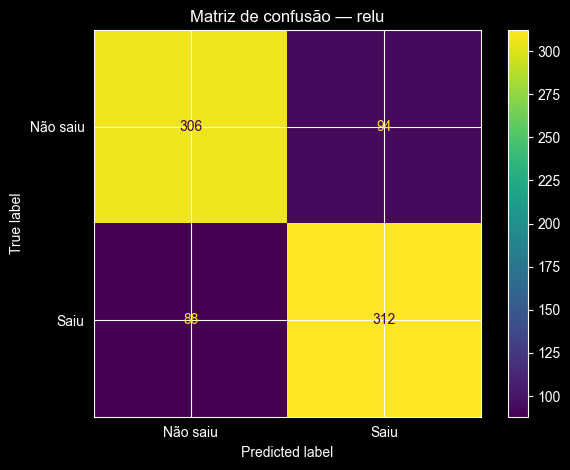

In [59]:
previsoes_melhor_modelo = melhor_modelo.predict(X_teste_processado)

probabilidades_melhor_modelo = (melhor_modelo.predict_proba(X_teste_processado)[:, 1])

ConfusionMatrixDisplay.from_predictions(y_teste,previsoes_melhor_modelo,display_labels=["Não saiu","Saiu"],values_format="d")

plt.title(f"Matriz de confusão — {melhor_ativacao}")

plt.tight_layout()
plt.show()


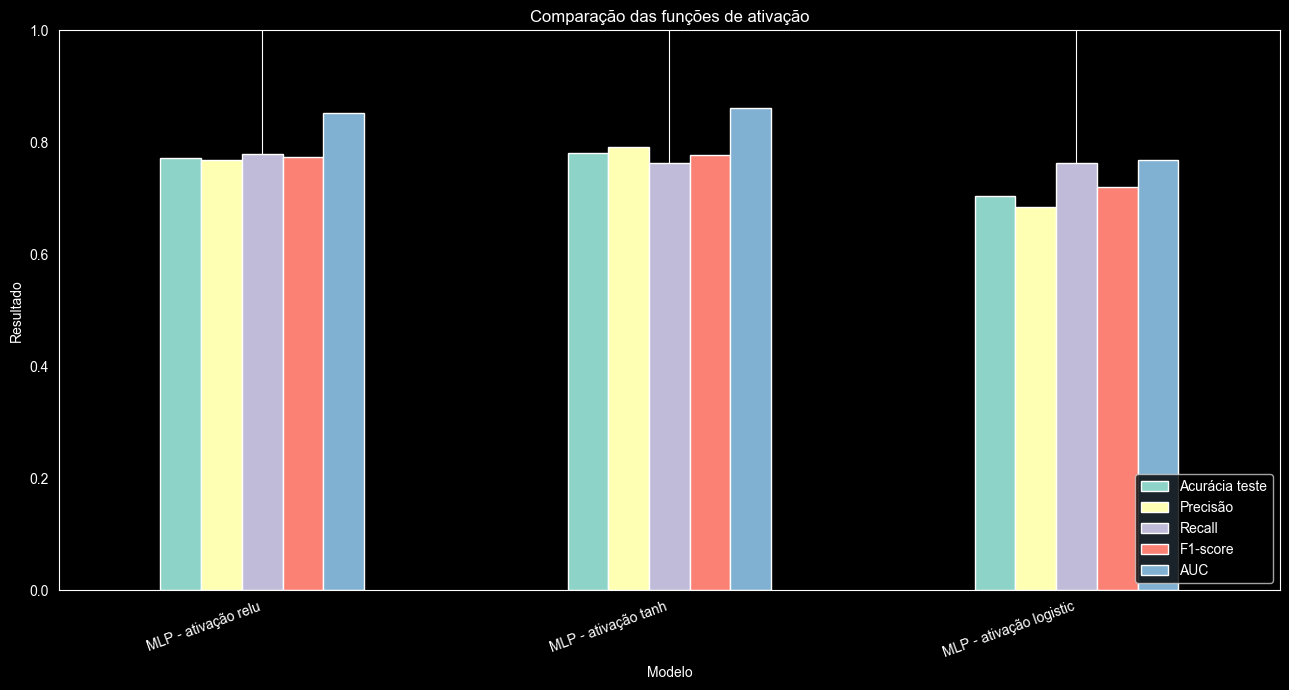

In [61]:
metricas_grafico = (resultados_ativacoes.set_index("Modelo")[[
            "Acurácia teste",
            "Precisão",
            "Recall",
            "F1-score",
            "AUC"]])

metricas_grafico.plot(kind="bar",figsize=(13, 7))

plt.title("Comparação das funções de ativação")

plt.xlabel("Modelo")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()